https://www.nature.com/articles/s43588-021-00158-0

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

class NetStates(nn.Module):
    '''нейросеть для предсказывания SIRD'''
    def __init__(self, layers = [1, 200, 100, 4]):
        super().__init__()

        # TODO нужно подумать насчет кол-ва нейронов
        # почему не степень 2?
        self.fc1 = nn.Linear(1, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, 4)

        self.activation = torch.tanh

        # Инициализация Xavier
        # nn.init.xavier_normal_(self.fc1.weight)
        # nn.init.xavier_normal_(self.fc2.weight)
        # nn.init.xavier_normal_(self.out.weight)
        # nn.init.zeros_(self.fc1.bias)
        # nn.init.zeros_(self.fc2.bias)
        # nn.init.zeros_(self.out.bias)

    def forward(self, t):
        x = self.activation(self.bn1(self.fc1(t)))
        x = self.activation(self.bn2(self.fc2(x)))
        x = self.activation(self.bn3(self.fc3(x)))
        return self.out(x)
    

class NetParameter(nn.Module):
    '''Нейросеть для параметра как функции от времени'''
    def __init__(self, layers = [1, 50, 50, 1]):
        super().__init__()

        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.out = nn.Linear(50, 1)

        nn.init.xavier_normal_(self.fc1.weight)
        nn.init.xavier_normal_(self.fc2.weight)
        nn.init.xavier_normal_(self.out.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.out.bias)

    def forward(self, t):
        x = torch.tanh(self.fc1(t))
        x = torch.tanh(self.fc2(x))
        return self.out(x)

class Nature_PINN(nn.Module):
    def __init__(self, t, S_data, I_data, R_data, D_data, device, train_size, population_n):
        super(Nature_PINN, self).__init__()

        self.device = device
        self.N = population_n
        self.train_size = train_size

        # Данные
        self.t = torch.tensor(t, requires_grad=True, device=self.device).float()
        self.t_batch = self.t.reshape(-1, 1)

        self.S = torch.tensor(S_data, device=device).float().reshape(-1, 1)
        self.I = torch.tensor(I_data, device=device).float().reshape(-1, 1)
        self.R = torch.tensor(R_data, device=device).float().reshape(-1, 1)
        self.D = torch.tensor(D_data, device=device).float().reshape(-1, 1)

        # Границы для масштабирования времени
        self.lb = torch.tensor(0, device=device).float()
        self.ub = torch.tensor(torch.max(self.t), device=device).float()

        # Масштабирование времение в [-1, 1] (как в статье)
        # self.t_scaled = 2.0 * (self.t_batch - self.lb) / (self.ub - self.lb) - 1.0

        # Нормализация данных
        self.S_max = self.S[:train_size].max()
        self.I_max = self.I[:train_size].max()
        self.D_max = self.D[:train_size].max()
        self.R_max = self.R[:train_size].max()
        self.S_min = self.S[:train_size].min()
        self.I_min = self.I[:train_size].min()
        self.D_min = self.D[:train_size].min()
        self.R_min = self.R[:train_size].min()
        
        self.S_hat = (self.S - self.S_min) / (self.S_max - self.S_min)
        self.I_hat = (self.I - self.I_min) / (self.I_max - self.I_min)
        self.D_hat = (self.D - self.D_min) / (self.D_max - self.D_min)
        self.R_hat = (self.R - self.R_min) / (self.R_max - self.R_min)

        # Инициализация сетей
        # Сеть для состояний
        self.net_states = NetStates().to(self.device)

        # Отдельные сети для параметров (как в статье)
        self.net_beta = NetParameter().to(self.device)
        self.net_gamma = NetParameter().to(self.device)
        self.net_mu = NetParameter().to(self.device)

        # Все обучаемые параметры
        self.params = (list(self.net_states.parameters()) + 
                       list(self.net_beta.parameters()) +
                       list(self.net_gamma.parameters()) +
                       list(self.net_mu.parameters()))
        
        # Для логирования
        self.losses = []

    @property
    def beta(self):
        '''β(t) в диапазоне [0, 1]'''
        return torch.sigmoid(self.net_beta(self.t_scaled))
    
    @property
    def gamma(self):
        '''γ(t) в диапазоне [0, 0.5] -- предполагается, что меньше 2-х дней люди не болеют'''
        return 0.5 * torch.sigmoid(self.net_gamma(self.t_scaled))
    
    @property
    def mu(self):
        '''μ(t) в диапазоне [0, 0.1] -- считаем, что летальность выше 10% маловероятна для гриппа'''
        return 0.1 * torch.sigmoid(self.net_mu(self.t_scaled))
    
    def net_f(self):
        '''ВЫчисление невязок'''
        t_batch = self.t_batch.clone().detach().requires_grad_(True)

        t_scaled = 2.0 * (t_batch - self.lb) / (self.ub - self.lb) - 1.0

        # Получение предсказания (нормализованные)
        states_hat = self.net_states(t_scaled)
        S_hat, I_hat, R_hat, D_hat = states_hat[:, 0:1], states_hat[:, 1:2], states_hat[:, 2:3], states_hat[:, 3:4]

        # Денормализация
        S = self.S_min + (self.S_max - self.S_min) * S_hat
        I = self.I_min + (self.I_max - self.I_min) * I_hat
        R = self.R_min + (self.R_max - self.R_min) * R_hat
        D = self.D_min + (self.D_max - self.D_min) * D_hat

        # Параметры эпидемии
        # beta =  self.beta
        # gamma = self.gamma
        # mu = self.mu

        # Производные нормализованных переменных
        S_hat_t = torch.autograd.grad(S_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        I_hat_t = torch.autograd.grad(I_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        R_hat_t = torch.autograd.grad(R_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        D_hat_t = torch.autograd.grad(D_hat.sum(), t_batch, 
                                  create_graph=True)[0]
        
        # Восстановление оригинальных производных (в тетради\miro есть вывод формулы)
        S_t = (self.S_max - self.S_min) * S_hat_t
        I_t = (self.I_max - self.I_min) * I_hat_t
        R_t = (self.R_max - self.R_min) * R_hat_t
        D_t = (self.D_max - self.D_min) * D_hat_t

        beta = torch.sigmoid(self.net_beta(t_scaled))
        gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)) 
        mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)) 

        # Уравнения SIRD
        dS = - beta * I * S / self.N
        dI = beta * I * S / self.N - gamma * I - mu * I
        dR = gamma * I
        dD = mu * I
        
        # Невязки в реальных масштабах
        f_S = S_t - dS
        f_I = I_t - dI
        f_R = R_t - dR
        f_D = D_t - dD

        # Conservation (как в статье)
        # TODO пока без этого попробую
        f_con = (S + I + R + D - self.N) / self.N  # можно нормализовать для loss

        # для ошибки по данным возьму нормализованные значения
        return f_S, f_I, f_R, f_D, S_hat, I_hat, R_hat, D_hat, beta, gamma, mu
    
    def loss_function(self):
        '''Вычисление функции потерь'''
        f_S, f_I, f_R, f_D, S_pred, I_pred, R_pred, D_pred, beta, gamma, mu = self.net_f()
    
        # Индексы для обучающей выборки
        idx = slice(self.train_size)

        # Ошибка на данных 
        loss_data = (0.0 * torch.mean((S_pred[idx] - self.S_hat[idx])**2) + 
                     1.0 * torch.mean((I_pred[idx] - self.I_hat[idx])**2) +
                     0.0 * torch.mean((R_pred[idx] - self.R_hat[idx])**2) +
                     0.0 * torch.mean((D_pred[idx] - self.D_hat[idx])**2))
        
        # Ошибка на начальных условиях
        # TODO пока отключу, это и так есть в невязке по данным
        loss_ic = (torch.mean((S_pred[0] - self.S_hat[0])**2) +
                   torch.mean((I_pred[0] - self.I_hat[0])**2) +
                   torch.mean((R_pred[0] - self.R_hat[0])**2) +
                   torch.mean((D_pred[0] - self.D_hat[0])**2))
        
        # Невязка по уравнениям SIRD
        loss_phys = (torch.mean(f_S**2) +
                     torch.mean(f_I**2) + 
                     torch.mean(f_R**2) +
                     torch.mean(f_D**2))
        
        # Регуляризация параметров (для гладкости)
        # TODO пока без этого, если значения будут прыгать, то включу
        # beta, gamma, mu = self.beta, self.gamma, self.mu
        loss_reg = (torch.mean((beta[1:] - beta[:-1])**2) +
                    torch.mean((gamma[1:] - gamma[:-1])**2) +
                    torch.mean((mu[1:] - mu[:-1])**2)) * 0.001
        
        # Итоговая потеря
        total_loss = (1.0 * loss_data +
                      1.0 * loss_phys)
        
        return total_loss, loss_data, loss_phys

    def train(self, n_epoch = 20000):
        '''Обучение модели'''
        print('\n' + '='*60)
        print('НАЧАЛО ОБУЧЕНИЯ')
        print('='*60)

        optimizer = optim.Adam(self.params, lr=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=1000
        )

        for epoch in range(n_epoch):
            optimizer.zero_grad()

            total_loss, loss_data, loss_phys = self.loss_function()
            total_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.params, max_norm=1.0)
            # for name, param in self.net_states.named_parameters():
            #     if param.grad is not None:
            #         print(f"{name} grad mean: {param.grad.abs().mean().item():.2e}")

            optimizer.step()
            scheduler.step(total_loss)
            
            self.losses.append(total_loss.item())

            if epoch % 1000 == 0:
                print(f'\nЭпоха {epoch:5d}:')
                print(f'  Total Loss: {total_loss.item():.2e}')
                print(f'  Data Loss: {loss_data.item():.2e}')
                print(f'  Physics Loss: {loss_phys.item():.2e}')
                
                # Статистика параметров
                with torch.no_grad():

                    t_batch = self.t_batch
                    t_scaled = 2.0 * (t_batch - self.lb) / (self.ub - self.lb) - 1.0

                    beta = torch.sigmoid(self.net_beta(t_scaled))
                    gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)) 
                    mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)) 

                    beta_mean = beta.mean().item()
                    gamma_mean = gamma.mean().item()
                    mu_mean = mu.mean().item()

                    print(f'  β mean: {beta_mean:.4f} [min: {beta.min().item():.4f}, max: {beta.max().item():.4f}]')
                    print(f'  γ mean: {gamma_mean:.4f} [min: {gamma.min().item():.4f}, max: {gamma.max().item():.4f}]')
                    print(f'  μ mean: {mu_mean:.4f} [min: {mu.min().item():.4f}, max: {mu.max().item():.4f}]')


    def predict(self, t_new = None):
        '''Предсказания'''
        if t_new is None:
            t_tensor = self.t_batch
        else:
            t_tensor = torch.tensor(t_new, device=self.device).float().reshape(-1, 1)
        t_scaled = 2.0 * (t_tensor - self.lb) / (self.ub - self.lb) - 1.0

        with torch.no_grad():
            states_hat = self.net_states(t_scaled)
            S_hat, I_hat, R_hat, D_hat = states_hat[:, 0], states_hat[:, 1], states_hat[:, 2], states_hat[:, 3]

            # Денормализация
            S = self.S_min + (self.S_max - self.S_min) * S_hat
            I = self.I_min + (self.I_max - self.I_min) * I_hat
            R = self.R_min + (self.R_max - self.R_min) * R_hat
            D = self.D_min + (self.D_max - self.D_min) * D_hat

            # Параметры (t_scaled могут быть новыми, поэтому не property вызов)
            beta = torch.sigmoid(self.net_beta(t_scaled)).flatten()
            gamma = 0.5 * torch.sigmoid(self.net_gamma(t_scaled)).flatten()
            mu = 0.1 * torch.sigmoid(self.net_mu(t_scaled)).flatten() + 0.0001

        return {
            'S': S.cpu().detach().numpy(),
            'I': I.cpu().detach().numpy(),
            'R': R.cpu().detach().numpy(),
            'D': D.cpu().detach().numpy(),
            'beta': beta.cpu().detach().numpy(),
            'gamma': gamma.cpu().detach().numpy(),
            'mu': mu.cpu().detach().numpy(),
            't': t_tensor.cpu().detach().numpy().flatten()
        }



In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

# Загрузка данных
covid_cases = pd.read_csv('./real_datasets/covid-19_Kouprianov.csv')
# covid_cases = pd.read_csv('sird_data_01_006_0003.csv')
# covid_cases = pd.read_csv('simulation.csv')

# Получаем данные
S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values
timesteps = np.arange(len(S)).astype(float)

# Параметры
train_size = 180  # размер обучающей выборки
population = S[0] + I[0] + R[0] + D[0]  # Общая популяция в начале

print(f"Всего точек данных: {len(timesteps)}")
print(f"Обучающих точек: {train_size}")
print(f"Тестовых точек: {len(timesteps) - train_size}")

Using device: cuda
Всего точек данных: 369
Обучающих точек: 180
Тестовых точек: 189


In [13]:
model.I_max

tensor(86474., device='cuda:0')

In [15]:
model.I_min

tensor(4197., device='cuda:0')

In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np


class NetStates(nn.Module):
    '''Улучшенная нейросеть для предсказания SIRD с учетом масштаба'''
    
    def __init__(self, layers=[1, 256, 256, 128, 4]):
        super().__init__()
        
        # Более глубокая сеть для большей выразительности
        self.fc1 = nn.Linear(1, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 4)
        
        # Инициализация Xavier с учетом масштаба
        for layer in [self.fc1, self.fc2, self.fc3, self.out]:
            nn.init.xavier_normal_(layer.weight, gain=0.5)
            nn.init.zeros_(layer.bias)
        
        # BatchNorm для стабильности
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        
    def forward(self, t):
        x = torch.tanh(self.bn1(self.fc1(t)))
        x = torch.tanh(self.bn2(self.fc2(x)))
        x = torch.tanh(self.bn3(self.fc3(x)))
        return self.out(x)


class NetParameter(nn.Module):
    '''Нейросеть для параметра как функции от времени'''
    
    def __init__(self, layers=[1, 64, 64, 1], output_scale=1.0, output_bias=0.0):
        super().__init__()
        
        self.output_scale = output_scale
        self.output_bias = output_bias
        
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
        
        for layer in [self.fc1, self.fc2, self.out]:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
        
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(64)
        
    def forward(self, t):
        x = torch.tanh(self.bn1(self.fc1(t)))
        x = torch.tanh(self.bn2(self.fc2(x)))
        x = self.out(x)
        # Масштабируем выход в нужный диапазон
        return self.output_scale * torch.sigmoid(x) + self.output_bias


class TorchStandardScaler:
    '''Нормализация данных с сохранением статистик'''
    
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, x, device):
        x = torch.tensor(x, device=device).float()
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, unbiased=False, keepdim=True)
        # Защита от нулевого std
        self.std = torch.where(self.std < 1e-6, torch.ones_like(self.std), self.std)
        
    def transform(self, x):
        return (x - self.mean) / self.std
    
    def fit_transform(self, x, device):
        self.fit(x, device)
        return self.transform(x)
    
    def inverse_transform(self, x):
        return x * self.std + self.mean


class ImprovedPINN(nn.Module):
    def __init__(self, t, S_data, I_data, R_data, D_data, device, train_size, population_n):
        super().__init__()
        
        self.device = device
        self.N = float(population_n)
        self.train_size = train_size
        self.eps = 1e-7
        
        # Данные
        self.t = torch.tensor(t, device=device).float()
        self.t_batch = self.t.reshape(-1, 1)
        
        # Масштабирование времени в [-1, 1]
        self.t_min = self.t.min()
        self.t_max = self.t.max()
        self.register_buffer('t_scaled', 2.0 * (self.t_batch - self.t_min) / 
                            (self.t_max - self.t_min + self.eps) - 1.0)
        
        # Исходные данные
        self.S_data = torch.tensor(S_data, device=device).float().reshape(-1, 1)
        self.I_data = torch.tensor(I_data, device=device).float().reshape(-1, 1)
        self.R_data = torch.tensor(R_data, device=device).float().reshape(-1, 1)
        self.D_data = torch.tensor(D_data, device=device).float().reshape(-1, 1)
        
        # Нормализация данных
        self.S_scaler = TorchStandardScaler()
        self.I_scaler = TorchStandardScaler()
        self.R_scaler = TorchStandardScaler()
        self.D_scaler = TorchStandardScaler()
        
        # Обучаем на тренировочных данных
        self.S_scaler.fit(S_data[:train_size], device)
        self.I_scaler.fit(I_data[:train_size], device)
        self.R_scaler.fit(R_data[:train_size], device)
        self.D_scaler.fit(D_data[:train_size], device)
        
        # Нормализованные данные для обучения
        self.S_norm = self.S_scaler.transform(self.S_data)
        self.I_norm = self.I_scaler.transform(self.I_data)
        self.R_norm = self.R_scaler.transform(self.R_data)
        self.D_norm = self.D_scaler.transform(self.D_data)
        
        # Инициализация сетей
        self.state_net = NetStates().to(device)
        
        # Сети для параметров с разными диапазонами
        # β(t) ∈ [0.01, 0.8] - коэффициент заражения
        self.beta_net = NetParameter(output_scale=0.79, output_bias=0.01).to(device)
        
        # γ(t) ∈ [0.02, 0.3] - скорость выздоровления
        self.gamma_net = NetParameter(output_scale=0.28, output_bias=0.02).to(device)
        
        # μ(t) ∈ [0.0001, 0.05] - смертность
        self.mu_net = NetParameter(output_scale=0.0499, output_bias=0.0001).to(device)
        
        # Все параметры
        self.params = (list(self.state_net.parameters()) +
                       list(self.beta_net.parameters()) +
                       list(self.gamma_net.parameters()) +
                       list(self.mu_net.parameters()))
        
        # Для логирования
        self.losses = []
        self.beta_history = []
        self.gamma_history = []
        self.mu_history = []
        
        print(f"Модель инициализирована. Население: {self.N:.0e}")
        print(f"Диапазон времени: [{self.t_min:.1f}, {self.t_max:.1f}]")
        
    def get_beta(self, t_scaled):
        '''β(t) - полностью зависит от времени'''
        return self.beta_net(t_scaled)
    
    def get_gamma(self, t_scaled):
        '''γ(t) - полностью зависит от времени'''
        return self.gamma_net(t_scaled)
    
    def get_mu(self, t_scaled):
        '''μ(t) - полностью зависит от времени'''
        return self.mu_net(t_scaled)
    
    def forward(self, t_scaled):
        '''Прямой проход для состояний с денормализацией'''
        states_norm = self.state_net(t_scaled)
        S_norm, I_norm, R_norm, D_norm = states_norm[:, 0:1], states_norm[:, 1:2], \
                                          states_norm[:, 2:3], states_norm[:, 3:4]
        
        # Денормализация
        S = self.S_scaler.inverse_transform(S_norm)
        I = self.I_scaler.inverse_transform(I_norm)
        R = self.R_scaler.inverse_transform(R_norm)
        D = self.D_scaler.inverse_transform(D_norm)
        
        # Гарантия неотрицательности и разумных пределов
        S = torch.clamp(F.softplus(S), min=0, max=self.N)
        I = torch.clamp(F.softplus(I), min=0, max=self.N)
        R = torch.clamp(F.softplus(R), min=0, max=self.N)
        D = torch.clamp(F.softplus(D), min=0, max=self.N)
        
        return S.flatten(), I.flatten(), R.flatten(), D.flatten()
    
    def compute_physics(self, t_scaled):
        '''Вычисление физических невязок'''
        t_scaled = t_scaled.clone().detach().requires_grad_(True)
        
        # Получаем состояния
        S, I, R, D = self.forward(t_scaled)
        
        # Вычисляем производные
        S_t = torch.autograd.grad(S.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        I_t = torch.autograd.grad(I.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        R_t = torch.autograd.grad(R.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        D_t = torch.autograd.grad(D.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        
        # Масштабируем производные обратно ко времени
        scale_factor = (self.t_max - self.t_min) / 2
        S_t = S_t * scale_factor
        I_t = I_t * scale_factor
        R_t = R_t * scale_factor
        D_t = D_t * scale_factor
        
        # Параметры (зависят от времени!)
        beta = self.get_beta(t_scaled).flatten()
        gamma = self.get_gamma(t_scaled).flatten()
        mu = self.get_mu(t_scaled).flatten()
        
        # Уравнения SIRD
        dS = -beta * I * S / (self.N + self.eps)
        dI = beta * I * S / (self.N + self.eps) - gamma * I - mu * I
        dR = gamma * I
        dD = mu * I
        
        # Невязки
        f_S = S_t - dS
        f_I = I_t - dI
        f_R = R_t - dR
        f_D = D_t - dD
        
        return {
            'S': S, 'I': I, 'R': R, 'D': D,
            'S_t': S_t, 'I_t': I_t, 'R_t': R_t, 'D_t': D_t,
            'dS': dS, 'dI': dI, 'dR': dR, 'dD': dD,
            'f_S': f_S, 'f_I': f_I, 'f_R': f_R, 'f_D': f_D,
            'beta': beta, 'gamma': gamma, 'mu': mu,
            't_scaled': t_scaled
        }
    
    def loss_function(self):
        '''Вычисление функции потерь'''
        physics = self.compute_physics(self.t_scaled)
        
        # Индексы для обучающей выборки
        idx = slice(self.train_size)
        
        # Ошибка по данным (в нормализованном пространстве)
        S_pred_norm = self.S_scaler.transform(physics['S'].reshape(-1, 1)).flatten()
        I_pred_norm = self.I_scaler.transform(physics['I'].reshape(-1, 1)).flatten()
        R_pred_norm = self.R_scaler.transform(physics['R'].reshape(-1, 1)).flatten()
        D_pred_norm = self.D_scaler.transform(physics['D'].reshape(-1, 1)).flatten()
        
        loss_data = (F.mse_loss(S_pred_norm[idx], self.S_norm[idx].flatten()) +
                    F.mse_loss(I_pred_norm[idx], self.I_norm[idx].flatten()) +
                    F.mse_loss(R_pred_norm[idx], self.R_norm[idx].flatten()) +
                    5.0 * F.mse_loss(D_pred_norm[idx], self.D_norm[idx].flatten()))
        
        # Физическая потеря
        loss_phys = (torch.mean(physics['f_S']**2) +
                    torch.mean(physics['f_I']**2) +
                    torch.mean(physics['f_R']**2) +
                    torch.mean(physics['f_D']**2))
        
        # Масштабируем физическую потерю
        loss_phys = loss_phys / (self.N**2 + self.eps) * 1e6
        
        # Регуляризация для гладкости параметров во времени
        beta, gamma, mu = physics['beta'], physics['gamma'], physics['mu']
        
        # Вычисляем производные параметров по времени
        t_scaled = physics['t_scaled']
        beta_t = torch.autograd.grad(beta.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        gamma_t = torch.autograd.grad(gamma.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        mu_t = torch.autograd.grad(mu.sum(), t_scaled, create_graph=True, retain_graph=True)[0]
        
        # Штрафуем большие изменения параметров (делаем их более гладкими)
        loss_param_smooth = (torch.mean(beta_t**2) + 
                            torch.mean(gamma_t**2) + 
                            torch.mean(mu_t**2)) * 0.01
        
        # Штрафуем осцилляции параметров
        loss_param_osc = (torch.mean((beta[1:] - beta[:-1])**2) +
                         torch.mean((gamma[1:] - gamma[:-1])**2) +
                         torch.mean((mu[1:] - mu[:-1])**2)) * 0.1
        
        # Сохранение суммы (консервация)
        total_pop = physics['S'] + physics['I'] + physics['R'] + physics['D']
        loss_conservation = torch.mean((total_pop - self.N)**2) / (self.N**2 + self.eps)
        
        # Итоговая потеря
        total_loss = (1.0 * loss_data + 
                     0.1 * loss_phys + 
                     0.01 * loss_param_smooth +
                     0.1 * loss_param_osc +
                     0.1 * loss_conservation)
        
        return total_loss, loss_data, loss_phys, loss_param_smooth, loss_param_osc, loss_conservation
    
    def train_model(self, n_epochs=30000, lr=1e-4):
        '''Обучение модели'''
        print('\n' + '='*60)
        print('НАЧАЛО ОБУЧЕНИЯ (параметры зависят от времени)')
        print('='*60)
        
        optimizer = optim.Adam(self.params, lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2000
        )
        
        for epoch in range(n_epochs):
            optimizer.zero_grad()
            
            total_loss, loss_data, loss_phys, loss_smooth, loss_osc, loss_cons = self.loss_function()
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.params, max_norm=1.0)
            
            optimizer.step()
            scheduler.step(total_loss)
            
            self.losses.append(total_loss.item())
            
            # Логирование параметров
            with torch.no_grad():
                beta = self.get_beta(self.t_scaled)
                gamma = self.get_gamma(self.t_scaled)
                mu = self.get_mu(self.t_scaled)
                
                beta_mean = beta.mean().item()
                gamma_mean = gamma.mean().item()
                mu_mean = mu.mean().item()
                
                beta_std = beta.std().item()
                gamma_std = gamma.std().item()
                mu_std = mu.std().item()
                
                self.beta_history.append(beta_mean)
                self.gamma_history.append(gamma_mean)
                self.mu_history.append(mu_mean)
            
            if epoch % 1000 == 0:
                print(f'\nЭпоха {epoch:5d}:')
                print(f'  Total Loss: {total_loss.item():.2e}')
                print(f'  Data Loss: {loss_data.item():.2e}')
                print(f'  Physics Loss: {loss_phys.item():.2e}')
                print(f'  Conservation Loss: {loss_cons.item():.2e}')
                print(f'  Params:')
                print(f'    β(t): mean={beta_mean:.4f}, std={beta_std:.4f}, range=[{beta.min().item():.4f}, {beta.max().item():.4f}]')
                print(f'    γ(t): mean={gamma_mean:.4f}, std={gamma_std:.4f}, range=[{gamma.min().item():.4f}, {gamma.max().item():.4f}]')
                print(f'    μ(t): mean={mu_mean:.4f}, std={mu_std:.4f}, range=[{mu.min().item():.4f}, {mu.max().item():.4f}]')
    
    def predict(self, t_new=None):
        '''Предсказание для новых временных точек'''
        if t_new is None:
            t_scaled = self.t_scaled
            t_orig = self.t_batch
        else:
            t_orig = torch.tensor(t_new, device=self.device).float().reshape(-1, 1)
            t_scaled = 2.0 * (t_orig - self.t_min) / (self.t_max - self.t_min + self.eps) - 1.0
        
        with torch.no_grad():
            S, I, R, D = self.forward(t_scaled)
            beta = self.get_beta(t_scaled).flatten().cpu().numpy()
            gamma = self.get_gamma(t_scaled).flatten().cpu().numpy()
            mu = self.get_mu(t_scaled).flatten().cpu().numpy()
        
        return {
            't': t_orig.cpu().numpy().flatten(),
            'S': S.cpu().numpy(),
            'I': I.cpu().numpy(),
            'R': R.cpu().numpy(),
            'D': D.cpu().numpy(),
            'beta': beta,
            'gamma': gamma,
            'mu': mu
        }

In [88]:
# Создание модели
# model = ImprovedPINN(
#     t=timesteps,
#     S_data=S,
#     I_data=I,
#     D_data=D,
#     R_data=R,
#     device=device,
#     train_size=train_size,
#     population_n=population
# )

# ============================================================
# ОБУЧЕНИЕ МОДЕЛИ
# ============================================================

# Обучаем модель
# model.train_model(n_epochs=100000)

# ============================================================
# ПОЛУЧЕНИЕ ПРОГНОЗА
# ============================================================

# Вариант 1: Прогноз на все временные точки (обучение + тест)
predictions = model.predict()  # без аргументов - использует все обучающие точки

# Извлекаем результаты
S_pred = predictions['S']
I_pred = predictions['I']
R_pred = predictions['R']
D_pred = predictions['D']
beta_pred = predictions['beta']
gamma_pred = predictions['gamma']
mu_pred = predictions['mu']
t_pred = predictions['t']

In [ ]:
# Создание модели
model = Nature_PINN(
    t=timesteps,
    S_data=S,
    I_data=I,
    D_data=D,
    R_data=R,
    device=device,
    train_size=train_size,
    population_n=population
)

# ============================================================
# ОБУЧЕНИЕ МОДЕЛИ
# ============================================================

# Обучаем модель
model.train(n_epoch=10000)

# ============================================================
# ПОЛУЧЕНИЕ ПРОГНОЗА
# ============================================================

# Вариант 1: Прогноз на все временные точки (обучение + тест)
predictions = model.predict()  # без аргументов - использует все обучающие точки

# Извлекаем результаты
S_pred = predictions['S']
I_pred = predictions['I']
R_pred = predictions['R']
D_pred = predictions['D']
beta_pred = predictions['beta']
gamma_pred = predictions['gamma']
mu_pred = predictions['mu']
t_pred = predictions['t']

C:\Users\dinara\AppData\Local\Temp\ipykernel_2620\928306658.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.ub = torch.tensor(torch.max(self.t), device=device).float()


AttributeError: 'Nature_PINN' object has no attribute 'train_model'


ГРАФИКИ ПРЕДСКАЗАНИЙ SIRD
График сохранен в sird_results_sird.png


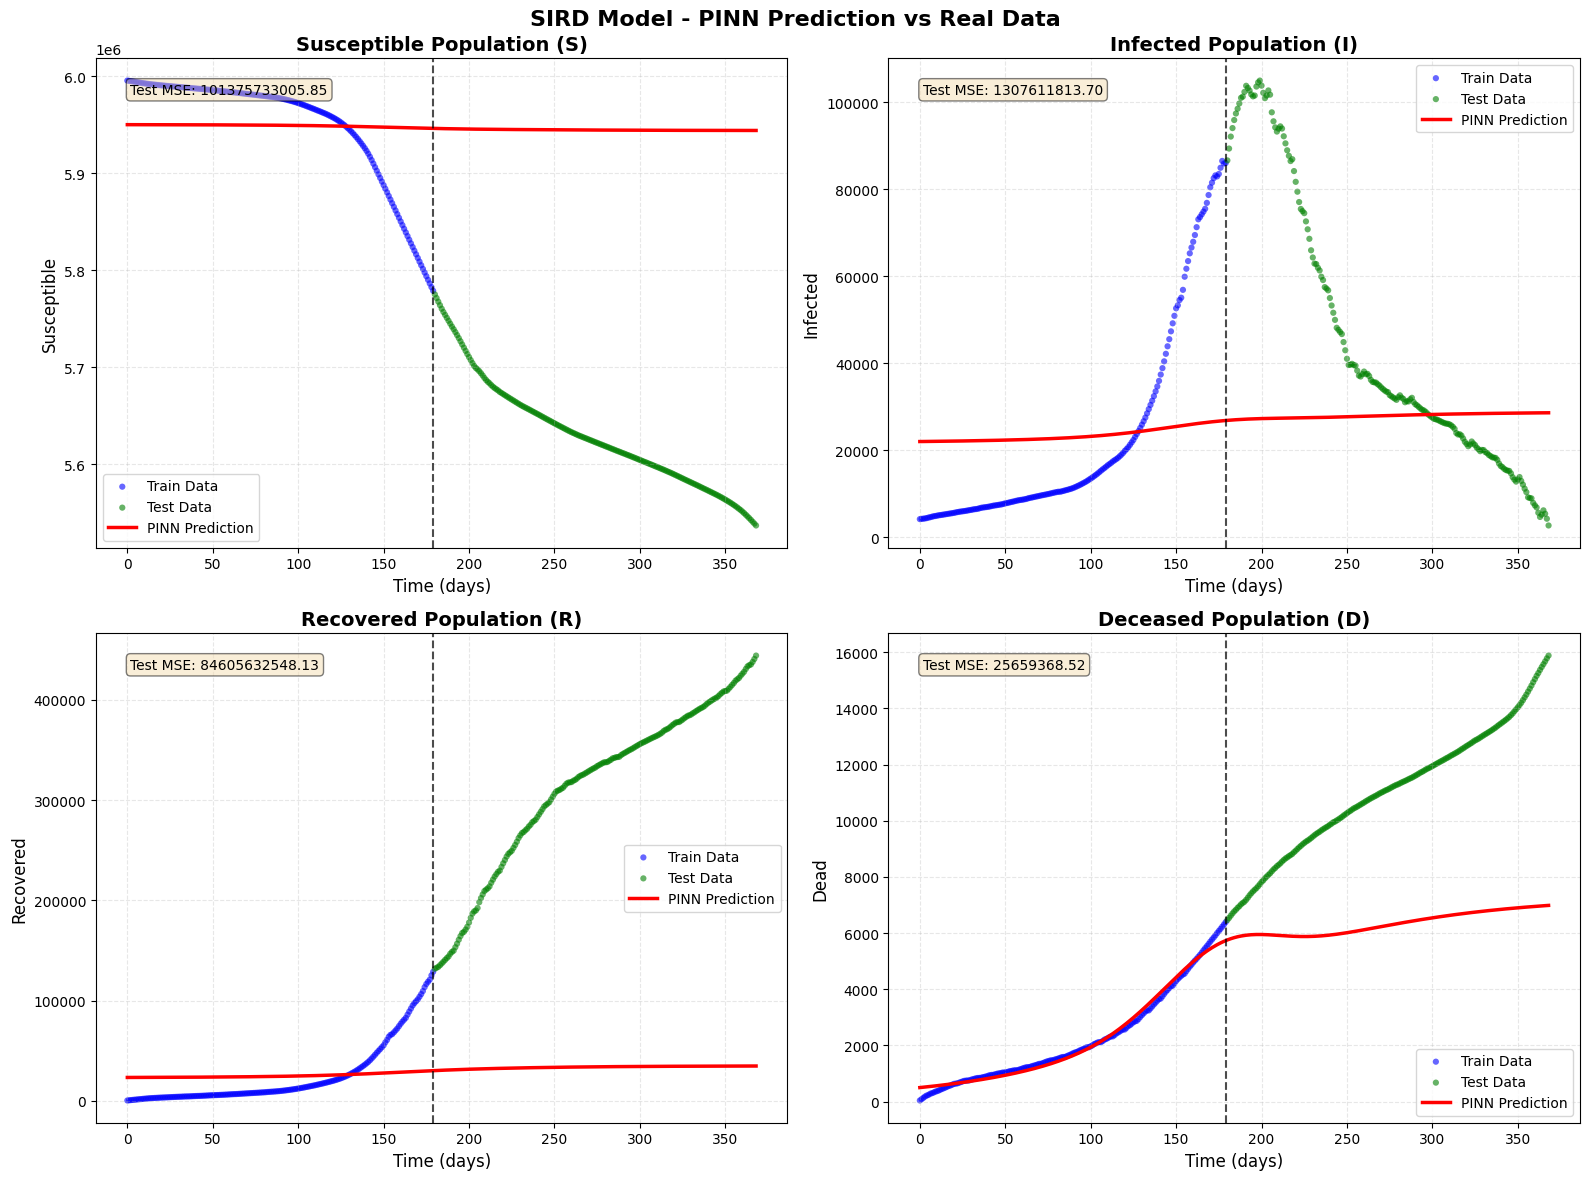


ГРАФИКИ ПАРАМЕТРОВ МОДЕЛИ
График параметров сохранен в sird_results_parameters.png


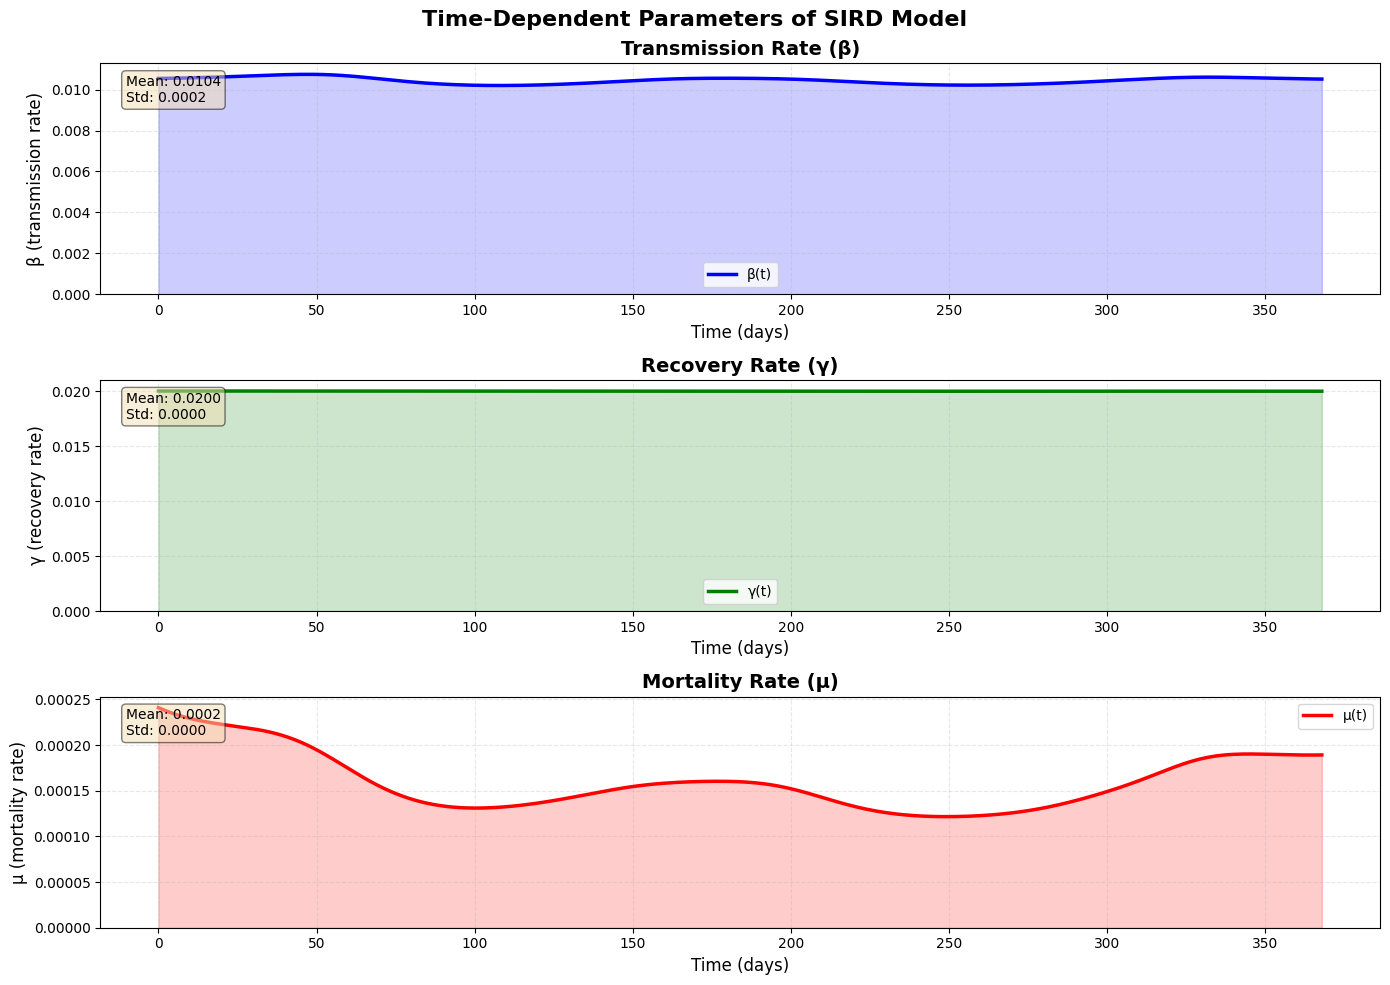


ГРАФИК ПОТЕРЬ
График потерь сохранен в sird_results_loss.png


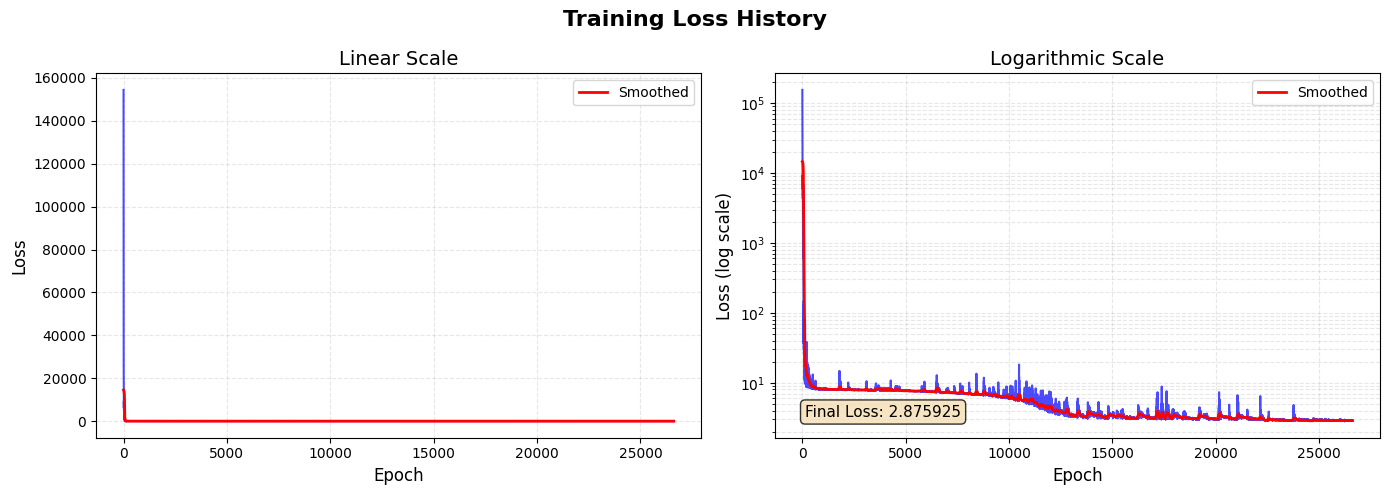


МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
S:
  MSE:  101375733005.8452
  MAE:  313515.7328
  RMSE: 318395.5606
  MAPE: 5.58%
I:
  MSE:  1307611813.7007
  MAE:  25608.2654
  RMSE: 36160.9156
  MAPE: 70.53%
R:
  MSE:  84605632548.1317
  MAE:  278845.9245
  RMSE: 290870.4738
  MAPE: 88.33%
D:
  MSE:  25659368.5175
  MAE:  4680.3356
  RMSE: 5065.5077
  MAPE: 40.45%


In [89]:
# Функция для отрисовки результатов SIRD
def plot_sird_results(timesteps, train_size, 
                      S_data, I_data, R_data, D_data,
                      S_pred, I_pred, R_pred, D_pred,
                      save_path=None):
    """
    Отображение результатов предсказания SIRD модели
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('SIRD Model - PINN Prediction vs Real Data', fontsize=16, fontweight='bold')
    
    # Вертикальная линия разделяющая train/test
    train_test_line = timesteps[train_size - 1] if train_size < len(timesteps) else timesteps[-1]
    
    # Цвета
    colors = {
        'train': 'blue',
        'test': 'green',
        'pred': 'red',
        'split': 'black'
    }
    
    # 1. Susceptible (S)
    ax = axes[0, 0]
    ax.scatter(timesteps[:train_size], S_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], S_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, S_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Susceptible', fontsize=12)
    ax.set_title('Susceptible Population (S)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Добавляем текст с метриками
    if train_size < len(timesteps):
        mse_test = np.mean((S_data[train_size:] - S_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Infected (I)
    ax = axes[0, 1]
    ax.scatter(timesteps[:train_size], I_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], I_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, I_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Infected', fontsize=12)
    ax.set_title('Infected Population (I)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((I_data[train_size:] - I_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 3. Recovered (R)
    ax = axes[1, 0]
    ax.scatter(timesteps[:train_size], R_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], R_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, R_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Recovered', fontsize=12)
    ax.set_title('Recovered Population (R)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((R_data[train_size:] - R_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4. Dead (D)
    ax = axes[1, 1]
    ax.scatter(timesteps[:train_size], D_data[:train_size], 
              c=colors['train'], label='Train Data', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(timesteps[train_size:], D_data[train_size:], 
              c=colors['test'], label='Test Data', s=20, alpha=0.6, edgecolors='none')
    ax.plot(timesteps, D_pred, color=colors['pred'], label='PINN Prediction', linewidth=2.5)
    ax.axvline(x=train_test_line, color=colors['split'], linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Dead', fontsize=12)
    ax.set_title('Deceased Population (D)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if train_size < len(timesteps):
        mse_test = np.mean((D_data[train_size:] - D_pred[train_size:])**2)
        ax.text(0.05, 0.95, f'Test MSE: {mse_test:.2f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для отрисовки параметров во времени
def plot_parameters_over_time(t_pred, beta_pred, gamma_pred, mu_pred, save_path=None):
    """
    Отображение изменения параметров модели во времени
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle('Time-Dependent Parameters of SIRD Model', fontsize=16, fontweight='bold')
    
    # Бета (коэффициент заражения)
    ax = axes[0]
    ax.plot(t_pred, beta_pred, 'b-', linewidth=2.5, label='β(t)')
    ax.fill_between(t_pred, 0, beta_pred, alpha=0.2, color='blue')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('β (transmission rate)', fontsize=12)
    ax.set_title('Transmission Rate (β)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    # Статистика
    ax.text(0.02, 0.95, f'Mean: {beta_pred.mean():.4f}\nStd: {beta_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Гамма (коэффициент выздоровления)
    ax = axes[1]
    ax.plot(t_pred, gamma_pred, 'g-', linewidth=2.5, label='γ(t)')
    ax.fill_between(t_pred, 0, gamma_pred, alpha=0.2, color='green')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('γ (recovery rate)', fontsize=12)
    ax.set_title('Recovery Rate (γ)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    ax.text(0.02, 0.95, f'Mean: {gamma_pred.mean():.4f}\nStd: {gamma_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Мю (коэффициент смертности)
    ax = axes[2]
    ax.plot(t_pred, mu_pred, 'r-', linewidth=2.5, label='μ(t)')
    ax.fill_between(t_pred, 0, mu_pred, alpha=0.2, color='red')
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('μ (mortality rate)', fontsize=12)
    ax.set_title('Mortality Rate (μ)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    ax.text(0.02, 0.95, f'Mean: {mu_pred.mean():.4f}\nStd: {mu_pred.std():.4f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График параметров сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для отрисовки потерь
def plot_losses(losses, save_path=None):
    """
    Отображение кривой обучения
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training Loss History', fontsize=16, fontweight='bold')
    
    epochs = np.arange(len(losses))
    
    # Линейный масштаб
    ax = axes[0]
    ax.plot(epochs, losses, 'b-', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Linear Scale', fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Сглаженная кривая для линейного масштаба
    if len(losses) > 100:
        from scipy.ndimage import uniform_filter1d
        smoothed = uniform_filter1d(losses, size=100)
        ax.plot(epochs, smoothed, 'r-', linewidth=2, label='Smoothed')
        ax.legend()
    
    # Логарифмический масштаб
    ax = axes[1]
    ax.semilogy(epochs, losses, 'b-', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (log scale)', fontsize=12)
    ax.set_title('Logarithmic Scale', fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--', which='both')
    
    # Сглаженная кривая для логарифмического масштаба
    if len(losses) > 100:
        ax.semilogy(epochs, smoothed, 'r-', linewidth=2, label='Smoothed')
        ax.legend()
    
    # Добавляем информацию о финальной ошибке
    ax.text(0.05, 0.05, f'Final Loss: {losses[-1]:.6f}', 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График потерь сохранен в {save_path}")
    
    plt.show()
    
    return fig

# Функция для вычисления метрик
def calculate_metrics(S_data, I_data, R_data, D_data, 
                     S_pred, I_pred, R_pred, D_pred, train_size):
    """
    Вычисление метрик качества на тестовой выборке
    """
    if train_size >= len(S_data):
        print("Внимание: train_size больше или равен длине данных. Метрики считаются на всех данных.")
        test_mask = slice(None)
    else:
        test_mask = slice(train_size, None)
    
    # Метрики
    metrics = {}
    names = ['S', 'I', 'R', 'D']
    data = [S_data, I_data, R_data, D_data]
    pred = [S_pred, I_pred, R_pred, D_pred]
    
    print("\n" + "="*70)
    print("МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print("="*70)
    
    for name, d, p in zip(names, data, pred):
        # MSE
        mse = np.mean((d[test_mask] - p[test_mask])**2)
        # MAE
        mae = np.mean(np.abs(d[test_mask] - p[test_mask]))
        # RMSE
        rmse = np.sqrt(mse)
        # MAPE (избегаем деления на ноль)
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = np.mean(np.abs((d[test_mask] - p[test_mask]) / (d[test_mask] + 1e-10))) * 100
        
        metrics[name] = {
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape
        }
        
        print(f"{name}:")
        print(f"  MSE:  {mse:.4f}")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAPE: {mape:.2f}%")
    
    print("="*70)
    
    return metrics

# Функция для отрисовки всех графиков вместе
def plot_all_results(timesteps, train_size,
                    S_data, I_data, R_data, D_data,
                    predictions, losses,
                    save_prefix=None):
    """
    Отображение всех графиков
    """
    # 1. Графики SIRD
    print("\n" + "="*70)
    print("ГРАФИКИ ПРЕДСКАЗАНИЙ SIRD")
    print("="*70)
    
    fig1 = plot_sird_results(
        timesteps, train_size,
        S_data, I_data, R_data, D_data,
        predictions['S'], predictions['I'], 
        predictions['R'], predictions['D'],
        save_path=f"{save_prefix}_sird.png" if save_prefix else None
    )
    
    # 2. Графики параметров
    print("\n" + "="*70)
    print("ГРАФИКИ ПАРАМЕТРОВ МОДЕЛИ")
    print("="*70)
    
    fig2 = plot_parameters_over_time(
        predictions['t'], 
        predictions['beta'],
        predictions['gamma'],
        predictions['mu'],
        save_path=f"{save_prefix}_parameters.png" if save_prefix else None
    )
    
    # 3. График потерь
    print("\n" + "="*70)
    print("ГРАФИК ПОТЕРЬ")
    print("="*70)
    
    fig3 = plot_losses(
        losses,
        save_path=f"{save_prefix}_loss.png" if save_prefix else None
    )
    
    # 4. Метрики
    metrics = calculate_metrics(
        S_data, I_data, R_data, D_data,
        predictions['S'], predictions['I'],
        predictions['R'], predictions['D'],
        train_size
    )
    
    return fig1, fig2, fig3, metrics


losses = model.losses  # или model.train_losses, в зависимости от реализации

# Отображаем все графики
fig1, fig2, fig3, metrics = plot_all_results(
    timesteps=timesteps,
    train_size=train_size,
    S_data=S,
    I_data=I,
    R_data=R,
    D_data=D,
    predictions=predictions,
    losses=losses,
    save_prefix='sird_results'  # опционально, для сохранения файлов
)

In [9]:
I_pred

array([ 7.80517578e+00,  7.71923828e+00,  7.64794922e+00,  7.57080078e+00,
        7.49267578e+00,  7.41308594e+00,  7.33935547e+00,  7.26660156e+00,
        7.18798828e+00,  7.11621094e+00,  7.04296875e+00,  6.96533203e+00,
        6.89892578e+00,  6.82861328e+00,  6.76025391e+00,  6.68750000e+00,
        6.61767578e+00,  6.54638672e+00,  6.47900391e+00,  6.41406250e+00,
        6.34765625e+00,  6.28125000e+00,  6.21093750e+00,  6.14697266e+00,
        6.08447266e+00,  6.01708984e+00,  5.95947266e+00,  5.89648438e+00,
        5.83154297e+00,  5.76855469e+00,  5.70654297e+00,  5.64990234e+00,
        5.58593750e+00,  5.52783203e+00,  5.46679688e+00,  5.41308594e+00,
        5.35546875e+00,  5.29296875e+00,  5.23486328e+00,  5.18212891e+00,
        5.12695312e+00,  5.07275391e+00,  5.01757812e+00,  4.95800781e+00,
        4.90771484e+00,  4.85253906e+00,  4.80078125e+00,  4.75292969e+00,
        4.69238281e+00,  4.64648438e+00,  4.59619141e+00,  4.54345703e+00,
        4.49462891e+00,  